
================ 原始資料前5列 ================
        date      close    ret_1d  ma20  mom60
0 2019-01-02  14.542258       NaN   NaN    NaN
1 2019-01-03  14.404789 -0.009453   NaN    NaN
2 2019-01-04  14.178945 -0.015678   NaN    NaN
3 2019-01-07  14.522618  0.024238   NaN    NaN
4 2019-01-08  14.463706 -0.004057   NaN    NaN

================ 策略淨值最後5列 ================
           date    nav_bh  nav_ma20  nav_mom60     dd_bh   dd_ma20  dd_mom60
1485 2025-02-21  3.332171  2.182072   1.805451 -0.018171 -0.152164 -0.217321
1486 2025-02-24  3.302712  2.162781   1.789490 -0.026851 -0.159659 -0.224240
1487 2025-02-25  3.259787  2.159699   1.766232 -0.039499 -0.160857 -0.234323
1488 2025-02-26  3.277462  2.159699   1.775808 -0.034290 -0.160857 -0.230171
1489 2025-02-27  3.240429  2.159699   1.755743 -0.045202 -0.160857 -0.238870

================ 績效總表 Preview ================
     strategy cumulative_return annualized_return annualized_volatility  \
0  Buy & Hold           224.04%            22.

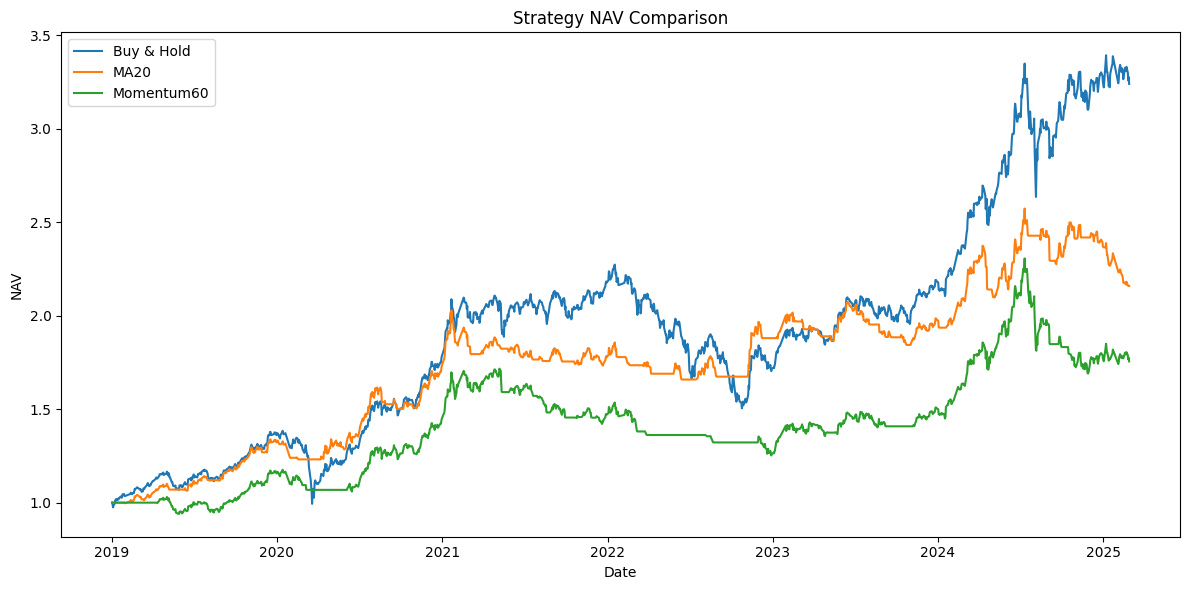

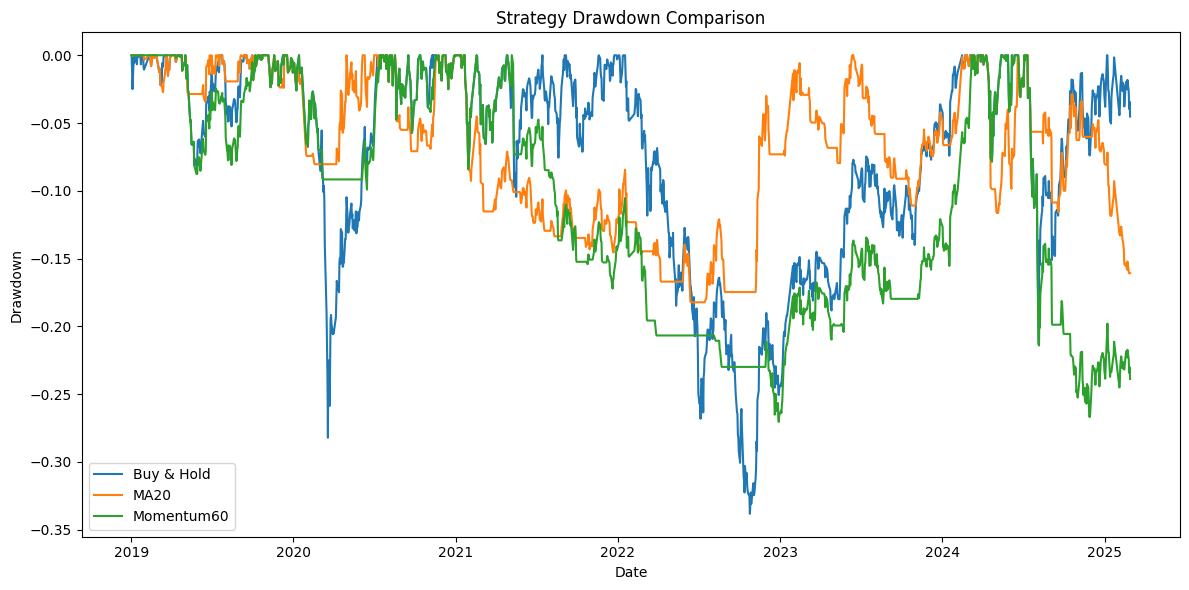


Done. Files saved in outputs/
已輸出：
- outputs/strategy_summary.csv
- outputs/dataset_for_tableau.csv
- outputs/equity_curve.png
- outputs/drawdown_curve.png


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

# =========================
# 0. Config
# =========================
TICKER = "0050.TW"
START_DATE = "2019-01-01"
END_DATE = "2025-03-01"
TRADING_COST = 0.001425

os.makedirs("outputs", exist_ok=True)

# =========================
# 1. Download data
# =========================
df = yf.download(TICKER, start=START_DATE, end=END_DATE, auto_adjust=True, progress=False)

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df = df.reset_index()
df.columns = [str(c).lower() for c in df.columns]
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

# =========================
# 2. Features
# =========================
df["ret_1d"] = df["close"].pct_change()
df["ma20"] = df["close"].rolling(20).mean()
df["mom60"] = df["close"].pct_change(60)

# =========================
# 3. Signals
# =========================
df["pos_bh"] = 1

df["signal_ma20"] = (df["close"] > df["ma20"]).astype(int)
df["pos_ma20"] = df["signal_ma20"].shift(1).fillna(0)

df["signal_mom60"] = (df["mom60"] > 0).astype(int)
df["pos_mom60"] = df["signal_mom60"].shift(1).fillna(0)

# =========================
# 4. Trading cost
# =========================
def trade_cost(position, cost_rate):
    turnover = position.fillna(0).diff().abs().fillna(position.fillna(0))
    return turnover * cost_rate

df["cost_bh"] = trade_cost(df["pos_bh"], TRADING_COST)
df["cost_ma20"] = trade_cost(df["pos_ma20"], TRADING_COST)
df["cost_mom60"] = trade_cost(df["pos_mom60"], TRADING_COST)

# =========================
# 5. Strategy returns
# =========================
df["strat_ret_bh"] = df["pos_bh"] * df["ret_1d"] - df["cost_bh"]
df["strat_ret_ma20"] = df["pos_ma20"] * df["ret_1d"] - df["cost_ma20"]
df["strat_ret_mom60"] = df["pos_mom60"] * df["ret_1d"] - df["cost_mom60"]

# =========================
# 6. NAV
# =========================
def compute_nav(ret):
    return (1 + ret.fillna(0)).cumprod()

df["nav_bh"] = compute_nav(df["strat_ret_bh"])
df["nav_ma20"] = compute_nav(df["strat_ret_ma20"])
df["nav_mom60"] = compute_nav(df["strat_ret_mom60"])

# =========================
# 7. Drawdown
# =========================
def drawdown(nav):
    peak = nav.cummax()
    return nav / peak - 1

df["dd_bh"] = drawdown(df["nav_bh"])
df["dd_ma20"] = drawdown(df["nav_ma20"])
df["dd_mom60"] = drawdown(df["nav_mom60"])

# =========================
# 8. Performance summary
# =========================
def annualized_return(nav, periods_per_year=252):
    nav = nav.dropna()
    total_return = nav.iloc[-1] / nav.iloc[0]
    years = len(nav) / periods_per_year
    return total_return ** (1 / years) - 1

def annualized_vol(ret, periods_per_year=252):
    return ret.dropna().std() * np.sqrt(periods_per_year)

def sharpe_ratio(ret, periods_per_year=252):
    ret = ret.dropna()
    vol = ret.std() * np.sqrt(periods_per_year)
    if vol == 0:
        return np.nan
    return (ret.mean() * periods_per_year) / vol

def max_drawdown(nav):
    return drawdown(nav).min()

summary = pd.DataFrame({
    "strategy": ["Buy & Hold", "MA20", "Momentum60"],
    "cumulative_return": [
        df["nav_bh"].iloc[-1] - 1,
        df["nav_ma20"].iloc[-1] - 1,
        df["nav_mom60"].iloc[-1] - 1
    ],
    "annualized_return": [
        annualized_return(df["nav_bh"]),
        annualized_return(df["nav_ma20"]),
        annualized_return(df["nav_mom60"])
    ],
    "annualized_volatility": [
        annualized_vol(df["strat_ret_bh"]),
        annualized_vol(df["strat_ret_ma20"]),
        annualized_vol(df["strat_ret_mom60"])
    ],
    "sharpe_ratio": [
        sharpe_ratio(df["strat_ret_bh"]),
        sharpe_ratio(df["strat_ret_ma20"]),
        sharpe_ratio(df["strat_ret_mom60"])
    ],
    "max_drawdown": [
        max_drawdown(df["nav_bh"]),
        max_drawdown(df["nav_ma20"]),
        max_drawdown(df["nav_mom60"])
    ]
})

summary.to_csv("outputs/strategy_summary.csv", index=False)

# =========================
# 9. Export data for Tableau
# =========================
tableau_df = pd.DataFrame({
    "date": df["date"],
    "nav_bh": df["nav_bh"],
    "nav_ma20": df["nav_ma20"],
    "nav_mom60": df["nav_mom60"],
    "dd_bh": df["dd_bh"],
    "dd_ma20": df["dd_ma20"],
    "dd_mom60": df["dd_mom60"]
})

tableau_df.to_csv("outputs/dataset_for_tableau.csv", index=False)

# =========================
# 10. Preview tables
# =========================
print("\n================ 原始資料前5列 ================")
print(df[["date", "close", "ret_1d", "ma20", "mom60"]].head())

print("\n================ 策略淨值最後5列 ================")
print(
    df[["date", "nav_bh", "nav_ma20", "nav_mom60",
        "dd_bh", "dd_ma20", "dd_mom60"]].tail()
)

summary_preview = summary.copy()
for col in ["cumulative_return", "annualized_return", "annualized_volatility", "max_drawdown"]:
    summary_preview[col] = summary_preview[col].map(lambda x: f"{x:.2%}")
summary_preview["sharpe_ratio"] = summary_preview["sharpe_ratio"].map(lambda x: f"{x:.2f}")

print("\n================ 績效總表 Preview ================")
print(summary_preview)

# =========================
# 11. Plot + Save + Show
# =========================
plt.figure(figsize=(12, 6))
plt.plot(df["date"], df["nav_bh"], label="Buy & Hold")
plt.plot(df["date"], df["nav_ma20"], label="MA20")
plt.plot(df["date"], df["nav_mom60"], label="Momentum60")
plt.title("Strategy NAV Comparison")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/equity_curve.png", dpi=200)
plt.show()   # 直接預覽
plt.close()

plt.figure(figsize=(12, 6))
plt.plot(df["date"], df["dd_bh"], label="Buy & Hold")
plt.plot(df["date"], df["dd_ma20"], label="MA20")
plt.plot(df["date"], df["dd_mom60"], label="Momentum60")
plt.title("Strategy Drawdown Comparison")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/drawdown_curve.png", dpi=200)
plt.show()   # 直接預覽
plt.close()

print("\nDone. Files saved in outputs/")
print("已輸出：")
print("- outputs/strategy_summary.csv")
print("- outputs/dataset_for_tableau.csv")
print("- outputs/equity_curve.png")
print("- outputs/drawdown_curve.png")

In [1]:
import yfinance as yf
import pandas as pd

# -----------------------------
# 1) 單一股票
# -----------------------------
df_single = yf.download("AAPL", start="2024-01-01", end="2024-01-10")

print("=== 單一股票資料 ===")
print(df_single)
print("\n=== df_single.head() ===")
print(df_single.head())

print("\n=== type(df_single) ===")
print(type(df_single))

print("\n=== df_single.index ===")
print(df_single.index)

print("\n=== type(df_single.index) ===")
print(type(df_single.index))

print("\n=== df_single.columns ===")
print(df_single.columns)

print("\n=== type(df_single.columns) ===")
print(type(df_single.columns))

print("\n=== 是否為 MultiIndex 欄位？===")
print(isinstance(df_single.columns, pd.MultiIndex))


# -----------------------------
# 2) 多股票
# -----------------------------
df_multi = yf.download(["AAPL", "TSLA"], start="2024-01-01", end="2024-01-10")

print("\n\n=== 多股票資料 ===")
print(df_multi)
print("\n=== df_multi.head() ===")
print(df_multi.head())

print("\n=== df_multi.index ===")
print(df_multi.index)

print("\n=== type(df_multi.index) ===")
print(type(df_multi.index))

print("\n=== df_multi.columns ===")
print(df_multi.columns)

print("\n=== type(df_multi.columns) ===")
print(type(df_multi.columns))

print("\n=== 是否為 MultiIndex 欄位？===")
print(isinstance(df_multi.columns, pd.MultiIndex))


# -----------------------------
# 3) 額外：把 columns 一個一個印出來
# -----------------------------
print("\n=== 單一股票 columns 逐個看 ===")
for col in df_single.columns:
    print(col)

print("\n=== 多股票 columns 逐個看 ===")
for col in df_multi.columns:
    print(col)

/tmp/ipykernel_55/96800398.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_single = yf.download("AAPL", start="2024-01-01", end="2024-01-10")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_55/96800398.py:36: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_multi = yf.download(["AAPL", "TSLA"], start="2024-01-01", end="2024-01-10")
[                       0%                       ]

=== 單一股票資料 ===
Price            Close        High         Low        Open    Volume
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL
Date                                                                
2024-01-02  183.731308  186.502522  181.999301  185.225777  82488700
2024-01-03  182.355560  183.968806  181.543984  182.325870  58414500
2024-01-04  180.039658  181.207518  179.020249  180.277180  71983600
2024-01-05  179.317184  180.880941  178.317574  180.118869  62379700
2024-01-08  183.652115  183.691712  179.633861  180.217791  59144500
2024-01-09  183.236435  183.246327  180.851210  182.028977  42841800

=== df_single.head() ===
Price            Close        High         Low        Open    Volume
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL
Date                                                                
2024-01-02  183.731308  186.502522  181.999301  185.225777  82488700
2024-01-03  182.355560  183.968806  181.543984  182.325870  58

[*********************100%***********************]  2 of 2 completed



=== 多股票資料 ===
Price            Close                    High                     Low  \
Ticker            AAPL        TSLA        AAPL        TSLA        AAPL   
Date                                                                     
2024-01-02  183.731308  248.419998  186.502522  251.250000  181.999301   
2024-01-03  182.355560  238.449997  183.968806  245.679993  181.543984   
2024-01-04  180.039658  237.929993  181.207518  242.699997  179.020249   
2024-01-05  179.317184  237.490005  180.880941  240.119995  178.317574   
2024-01-08  183.652115  240.449997  183.691712  241.250000  179.633861   
2024-01-09  183.236435  234.960007  183.246327  238.960007  180.851210   

Price                         Open                Volume             
Ticker            TSLA        AAPL        TSLA      AAPL       TSLA  
Date                                                                 
2024-01-02  244.410004  185.225777  250.080002  82488700  104654200  
2024-01-03  236.320007  182.325870  2